# Winter Wheat Phenology: PVTT vs Input-Gated Hybrid

Same comparison as `pvtt_wheat_exploration.ipynb`, but the hybrid model is
restructured.  Instead of a two-output-channel TTCNN whose cumulants are
multiplied to form heading probability (the "awkward" two-stage setup),
the **vernalization** and **photoperiod** factors are pre-computed (using
the PVTT functional forms) and passed as *input* features alongside
temperature and daylight.  The TTCNN then has a single output channel
whose cumulant is soft-thresholded to give heading probability.

Conceptually the network no longer has to *discover* the two-stage
structure; it receives the gating signals as inputs and just has to learn
how to combine them with the weather features.

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from typing import Any, Callable, Dict, List, Optional, Tuple

from pysephone.constants import KEY_FEATURES, KEY_OBSERVATIONS_INDEX
from pysephone.dataset.dataset import Dataset
from pysephone.dataset.util.calendar import Calendar
from pysephone.dataset.util.openmeteo import OpenMeteoFeatures
from pysephone.evaluation.regression import SingleTargetRegression
from pysephone.models.pvtt import PVTTModel
from pysephone.models.torch_base import BaseTorchModel
from pysephone.models.util.soft_threshold import SoftThreshold
from pysephone.models.util.ttcnn import TTCNN
from pysephone.models.util.func_phenology import (
    func_vernalization_unit,
    func_vernalization_tres,
    func_photoperiod_factor,
    func_growing_degree_units_2,
)
from pysephone.utils.func import create_left_mask as create_left_mask_np
from pysephone.utils.func_torch import create_left_mask

In [15]:
OBS_KEY = 'BBCH_51'
SOW_KEY = 'BBCH_0'
CUTOFF  = 2006          # train: 1986–2005, test: 2006–2015
DEVICE  = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Using device:', DEVICE)

PALETTE = {
    'temp_warm': '#f4a46280',
    'temp_cold': '#7eb8d480',
    'temp_line': '#c0392b',
    'zero':      '#cccccc',
    'thresh':    '#555555',
}
MODEL_COLORS = {
    'PVTT':         '#2980b9',
    'InputHybrid':  '#16a085',
    'vt':           '#8e44ad',
    'pf':           '#e67e22',
}

_MONTH_STARTS = [0, 31, 61, 92, 122, 153, 181, 212, 243, 273, 304, 334]
_MONTH_LABELS = ['Oct','Nov','Dec','Jan','Feb','Mar',
                  'Apr','May','Jun','Jul','Aug','Sep']

def _month_ticks(n):
    t = [d for d in _MONTH_STARTS if d < n]
    l = [_MONTH_LABELS[i] for i, d in enumerate(_MONTH_STARTS) if d < n]
    return t, l

def _style_ax(ax, n, ylabel='', xlabel=False):
    ax.set_xlim(0, n - 1)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.tick_params(labelsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    t, l = _month_ticks(n)
    ax.set_xticks(t)
    ax.set_xticklabels(l if xlabel else [], fontsize=8)
    if xlabel:
        ax.set_xlabel('Month (season from Oct 1)', fontsize=9)

Using device: cpu


## 1. Load data

In [16]:
cal      = Calendar(default_start='10-01', default_length=365)
features = OpenMeteoFeatures(calendar=cal)

ds_raw = Dataset.load('CPF_PEP725_winter_wheat', calendar=cal, feature_providers=[features])
ds_raw.download_features(verbose=True)

target_fn = lambda s: s['observations'][OBS_KEY]

years_trn = [y for y in ds_raw.years if y < CUTOFF]
years_tst = [y for y in ds_raw.years if y >= CUTOFF]

ds_trn = ds_raw.select_years(years_trn)
ds_tst = ds_raw.select_years(years_tst)

print(f'Train: {len(ds_trn)} samples  ({min(years_trn)}–{max(years_trn)})')
print(f'Test:  {len(ds_tst)} samples  ({min(years_tst)}–{max(years_tst)})')

def pick_sample(ds, year):
    for item in ds.iter_items():
        if item['year'] == year:
            return item
    raise ValueError(f'Year {year} not found')

years_to_show = years_tst[:3]

Preloading features: 100%|██████████| 5284/5284 [00:56<00:00, 92.98it/s] 

Train: 3537 samples  (1987–2005)
Test:  1747 samples  (2006–2015)


## 2. Calibrate PVTT

Fitted as in the original notebook.  We will reuse the calibrated
`threshold_vern`, `p_base`, `p_saturation` values to compute the same
`vt`/`pf` signals inside the hybrid model.

In [17]:
pvtt, pvtt_fit_info = PVTTModel.fit(
    target_fn = target_fn,
    dataset   = ds_trn,
    model_kwargs = dict(
        threshold_pvtt = 800.0,
        threshold_vern = 30.0,
        t_base         = 1.0,
        t_limit        = 32.0,
        t_upper        = 40.0,
        p_base         = 7.0,
        p_saturation   = 17.0,
        ix_start       = 0,
        key_sow        = SOW_KEY,
    ),
    verbose = True,
)
print('\nCalibrated PVTT parameters:')
for k, v in pvtt._params.items():
    print(f'  {k}: {v:.3f}')


Calibrated PVTT parameters:
  th_pvtt: 495.641
  th_vern: 39.580
  t_base: 1.318
  t_limit: 32.000
  t_upper: 40.000
  p_base: 8.486
  p_saturation: 19.049


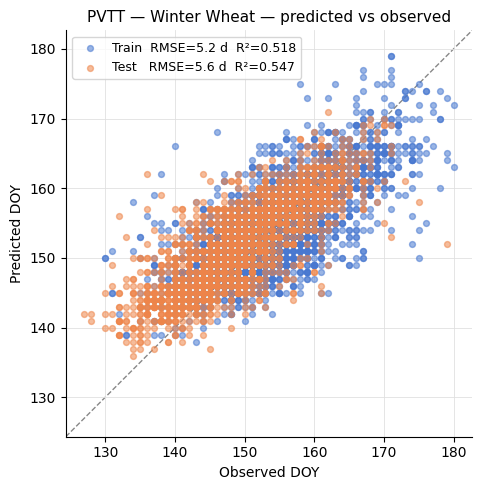

In [18]:
result_pvtt = SingleTargetRegression.run(
    model         = pvtt,
    dataset_train = ds_trn,
    dataset_test  = ds_tst,
    target_fn     = target_fn,
    run_name      = 'pvtt_wheat_v2',
)
m_pvtt = result_pvtt.compute_metrics()
fig = result_pvtt.plot_scatter(title='PVTT — Winter Wheat — predicted vs observed')
plt.show()

## 3. Input-gated hybrid model

Defined inline.  Architecture:

1. Compute `vt(t)` and `pf(t)` from temperature and daylight using the
   same functional forms as PVTT, with thresholds taken from the
   calibrated PVTT model.  These are **inputs**, not learned intermediate
   activations — they carry no gradient back into the network.
2. Feed `[T_norm, D_norm, vt, pf]` into a TTCNN with a single sigmoid
   output channel → per-day contribution in `[0, 1]`.
3. Mask by sowing, cumulate, soft-threshold → heading probability `ps(t)`.
4. Predicted day = `argmax(first_diff(ps))`.

BCE loss against a soft step-function target, identical to
`WheatHybridModel`.

In [19]:
def torch_vernalization_unit(t: torch.Tensor) -> torch.Tensor:
    """Trapezoidal vernalization unit:
        0 for T ≤ -4 or T ≥ 17; 1 for T ∈ [4, 10]; linear between.
    Matches `func_vernalization_unit` (np.interp on [-4, 4, 10, 17]).
    """
    left  = torch.clamp((t + 4.0) / 8.0, 0.0, 1.0)
    right = torch.clamp((17.0 - t) / 7.0, 0.0, 1.0)
    return torch.minimum(left, right)

def torch_vernalization_tres(cum_vu: torch.Tensor, threshold: float) -> torch.Tensor:
    """Ramp cumulative VU from 0 → threshold into a [0, 1] fulfilment factor."""
    return torch.clamp(cum_vu / threshold, 0.0, 1.0)

def torch_photoperiod_factor(daylight_h: torch.Tensor,
                              p_base: float, p_sat: float) -> torch.Tensor:
    """Linear ramp from `p_base` to `p_sat` daylight hours → [0, 1]."""
    return torch.clamp((daylight_h - p_base) / (p_sat - p_base), 0.0, 1.0)

In [20]:
class PVTTInputHybridModel(BaseTorchModel):
    """Single-channel TTCNN with pre-computed vt and pf as inputs.

    Inputs fed to the TTCNN at every timestep:
        - normalised temperature
        - normalised daylight duration
        - vernalization factor vt(t) ∈ [0, 1]  (PVTT closed form)
        - photoperiod factor   pf(t) ∈ [0, 1]  (PVTT closed form)

    The network learns the daily contribution; cumulating and
    soft-thresholding once gives heading probability.
    """

    def __init__(
        self,
        temperature_key: str = 'temperature_2m_mean',
        daylight_key:    str = 'daylight_duration',
        sow_key:         str = 'BBCH_0',
        feature_statistics: Optional[Dict[str, Tuple[float, float]]] = None,
        threshold_vern:  float = 30.0,
        p_base:          float = 7.0,
        p_saturation:    float = 17.0,
        hidden_size:     int   = 32,
        kernel_size:     int   = 7,
        num_layers:      int   = 4,
        use_dilations:   bool  = False,
        learn_threshold: bool  = True,
    ) -> None:
        super().__init__()

        self._temperature_key = temperature_key
        self._daylight_key    = daylight_key
        self._sow_key         = sow_key
        self._feature_statistics = (
            feature_statistics if feature_statistics is not None
            else self.__class__.get_default_norm_params()
        )

        # PVTT closed-form constants used to build vt and pf inputs
        self._threshold_vern = float(threshold_vern)
        self._p_base         = float(p_base)
        self._p_saturation   = float(p_saturation)

        # 4 input channels -> 1 output channel
        self._ttcnn = TTCNN(
            num_channels_in  = 4,
            num_channels_out = 1,
            hidden_size      = hidden_size,
            kernel_size      = kernel_size,
            num_layers       = num_layers,
            final_activation = nn.Sigmoid(),
            use_dilations    = use_dilations,
        )

        self._threshold = SoftThreshold(
            slope=40.0,
            slope_requires_grad=False,
            threshold_requires_grad=learn_threshold,
            slope_positive=True,
            threshold_positive=False,
            b0=0.0,
            b1=365.0,
        )

    # ------------------------------------------------------------------
    # Feature assembly
    # ------------------------------------------------------------------
    def _build_inputs(self, xs: Dict[str, Any]):
        """Return (feats (B,4,T), sow_mask (B,T), vt (B,T), pf (B,T))."""
        temp    = xs[KEY_FEATURES][self._temperature_key]            # (B, T) °C
        dayl_s  = xs[KEY_FEATURES][self._daylight_key]               # (B, T) seconds
        B, T    = temp.shape

        t_mean, t_std = self._feature_statistics[self._temperature_key]
        d_mean, d_std = self._feature_statistics[self._daylight_key]
        temp_norm = torch.nan_to_num((temp - t_mean) / t_std)
        dayl_norm = torch.nan_to_num((dayl_s - d_mean) / d_std)

        sow_ix   = xs[KEY_OBSERVATIONS_INDEX][self._sow_key].long()  # (B,)
        sow_mask = create_left_mask(T, sow_ix).float()               # (B, T)

        # vt and pf as inputs — no gradient through the closed forms.
        with torch.no_grad():
            vu     = torch_vernalization_unit(temp) * sow_mask
            vt     = torch_vernalization_tres(vu.cumsum(dim=-1),
                                              self._threshold_vern)
            dayl_h = dayl_s / 3600.0
            pf     = torch_photoperiod_factor(dayl_h, self._p_base,
                                              self._p_saturation)

        feats = torch.stack([temp_norm, dayl_norm, vt, pf], dim=1)   # (B, 4, T)
        feats = torch.nan_to_num(feats)
        return feats, sow_mask, vt, pf

    # ------------------------------------------------------------------
    # Forward
    # ------------------------------------------------------------------
    def forward(
        self, xs: Dict[str, Any], **kwargs: Any
    ) -> Tuple[torch.Tensor, Dict[str, Any]]:
        feats, sow_mask, vt, pf = self._build_inputs(xs)
        B, _, T = feats.shape

        contrib = self._ttcnn(feats)[:, 0, :] * sow_mask             # (B, T)
        cumul   = torch.cumsum(contrib, dim=-1)                      # (B, T)
        ps      = self._threshold(cumul.unsqueeze(1)).squeeze(1)     # (B, T)

        diff = ps - torch.roll(ps, 1, dims=-1)
        ixs  = torch.argmax(diff, dim=-1).clamp(0, T - 1)

        return ixs.float(), {
            'ps':       ps,
            'contrib':  contrib,
            'cumul':    cumul,
            'vt':       vt,
            'pf':       pf,
            'sow_mask': sow_mask,
        }

    # ------------------------------------------------------------------
    # BCE loss against soft step-function target
    # ------------------------------------------------------------------
    def loss(
        self,
        xs: Dict[str, Any],
        target_fn: Callable[[Dict[str, Any]], Any],
    ) -> Tuple[torch.Tensor, Dict[str, Any]]:
        ys_pred, info = self(xs)
        ps = info['ps']

        season_starts = xs['season_start']
        ys_true_list = []
        for i, season_start in enumerate(season_starts):
            sample = {k: v[i] if isinstance(v, (list, torch.Tensor)) else v
                      for k, v in xs.items()}
            target_dt = np.datetime64(target_fn(sample), 'D')
            start_dt  = np.datetime64(season_start, 'D')
            ix = int((target_dt - start_dt) / np.timedelta64(1, 'D'))
            ys_true_list.append(float(ix))

        ys_true = torch.tensor(ys_true_list, dtype=ps.dtype, device=ps.device)
        T = ps.size(-1)
        t_range = torch.arange(T, device=ps.device).unsqueeze(0)
        labels  = (t_range >= ys_true.view(-1, 1)).to(ps.dtype)

        loss = F.binary_cross_entropy(ps, labels)
        return loss, {
            'forward_pass': info,
            'ys_pred':      ys_pred,
            'ys_true':      ys_true,
        }

## 4. Fit the hybrid

PVTT's calibrated thresholds are passed in so the `vt` / `pf` inputs
carry the same signal the process-based model saw.

In [21]:
HYBRID_KWARGS = dict(
    threshold_vern   = pvtt.threshold_vern,
    p_base           = pvtt.p_base,
    p_saturation     = pvtt.p_saturation,
    hidden_size      = 32,
    kernel_size      = 7,
    num_layers       = 4,
    use_dilations    = False,
    learn_threshold  = True,
)

hybrid, hybrid_fit_info = PVTTInputHybridModel.fit(
    target_fn        = target_fn,
    dataset          = ds_trn,
    model_kwargs     = HYBRID_KWARGS,
    num_epochs       = 1000,
    batch_size       = 512,
    val_period       = 10,
    optimizer        = 'adam',
    optimizer_kwargs = dict(lr=1e-3, weight_decay=1e-4),
    scheduler_step_size      = 100,
    scheduler_decay          = 0.9,
    early_stopping           = True,
    early_stopping_patience  = 10,
    early_stopping_min_delta = 1e-3,
    early_stopping_rerun     = True,
    device  = DEVICE,
    verbose = True,
)
print('Input-gated hybrid training complete.')

PVTTInputHybridModel epoch [    1/1000] lr=1.00e-03 loss=0.89031: 100%|██████████| 6/6 [00:00<00:00, 13.05it/s]
PVTTInputHybridModel epoch [    2/1000] lr=1.00e-03 loss=0.18511: 100%|██████████| 6/6 [00:00<00:00, 13.22it/s]
PVTTInputHybridModel epoch [    3/1000] lr=1.00e-03 loss=0.18874: 100%|██████████| 6/6 [00:00<00:00, 13.06it/s]
PVTTInputHybridModel epoch [    4/1000] lr=1.00e-03 loss=0.11469: 100%|██████████| 6/6 [00:00<00:00, 12.46it/s]
PVTTInputHybridModel epoch [    5/1000] lr=1.00e-03 loss=0.08653: 100%|██████████| 6/6 [00:00<00:00, 13.73it/s]
PVTTInputHybridModel epoch [    6/1000] lr=1.00e-03 loss=0.08540: 100%|██████████| 6/6 [00:00<00:00, 13.76it/s]
PVTTInputHybridModel epoch [    7/1000] lr=1.00e-03 loss=0.07043: 100%|██████████| 6/6 [00:00<00:00, 13.13it/s]
PVTTInputHybridModel epoch [    8/1000] lr=1.00e-03 loss=0.07017: 100%|██████████| 6/6 [00:00<00:00, 13.39it/s]
PVTTInputHybridModel epoch [    9/1000] lr=1.00e-03 loss=0.06435: 100%|██████████| 6/6 [00:00<00:00, 13.

Input-gated hybrid training complete.


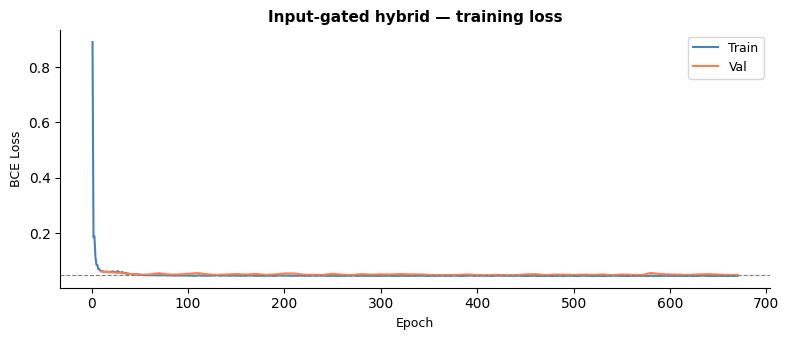

Learned soft-threshold: 0.477 (norm.) ≈ 174.0 acc. units


In [22]:
epochs   = [e['epoch'] for e in hybrid_fit_info['epochs']]
trn_loss = [e['loss']  for e in hybrid_fit_info['epochs']]
val_ep   = [e['epoch'] for e in hybrid_fit_info['epochs'] if 'val' in e]
val_loss = [e['val']['loss'] for e in hybrid_fit_info['epochs'] if 'val' in e]

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(epochs, trn_loss, label='Train', color='steelblue', lw=1.5)
if val_loss:
    ax.plot(val_ep, val_loss, label='Val', color='coral', lw=1.5)
    ax.axhline(min(val_loss), color='grey', ls='--', lw=0.8)
ax.set_xlabel('Epoch', fontsize=9)
ax.set_ylabel('BCE Loss', fontsize=9)
ax.set_title('Input-gated hybrid — training loss', fontsize=11, fontweight='bold')
ax.legend(fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

th = hybrid._threshold.threshold.item()
print(f'Learned soft-threshold: {th:.3f} (norm.) ≈ {th * 365:.1f} acc. units')

## 5. Evaluate and compare

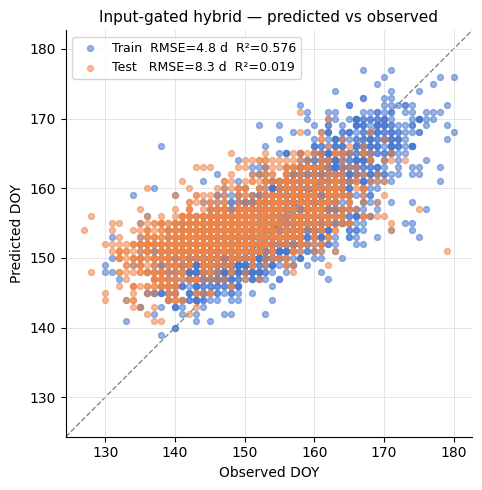

N  RMSE   MAE  Bias     R²
Model       Split                               
PVTT        train  3537  5.17  3.93 -0.09  0.518
            test   1747  5.62  4.32  2.45  0.547
InputHybrid train  3537  4.85  3.66  1.03  0.576
            test   1747  8.27  6.81  5.14  0.019

In [23]:
result_hybrid = SingleTargetRegression.run(
    model         = hybrid,
    dataset_train = ds_trn,
    dataset_test  = ds_tst,
    target_fn     = target_fn,
    run_name      = 'pvtt_input_hybrid',
)
fig = result_hybrid.plot_scatter(
    title='Input-gated hybrid — predicted vs observed'
)
plt.show()

m_hybrid = result_hybrid.compute_metrics()
rows = []
for name, m in [('PVTT', m_pvtt), ('InputHybrid', m_hybrid)]:
    for split in ('train', 'test'):
        rows.append({
            'Model': name, 'Split': split,
            'N':    m[split]['n'],
            'RMSE': round(m[split]['rmse'], 2),
            'MAE':  round(m[split]['mae'],  2),
            'Bias': round(m[split]['bias'], 2),
            'R²':   round(m[split]['r2'],   3),
        })
pd.DataFrame(rows).set_index(['Model', 'Split'])

## 6. TTCNN response map

Steady-state output of the single TTCNN channel when fed constant inputs,
swept over a temperature × daylight grid.  `vt` and `pf` are computed
from those inputs the same way the model does at training time.

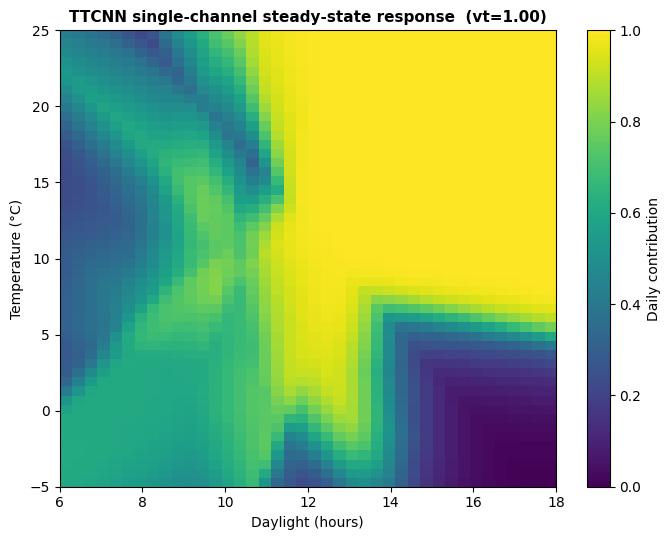

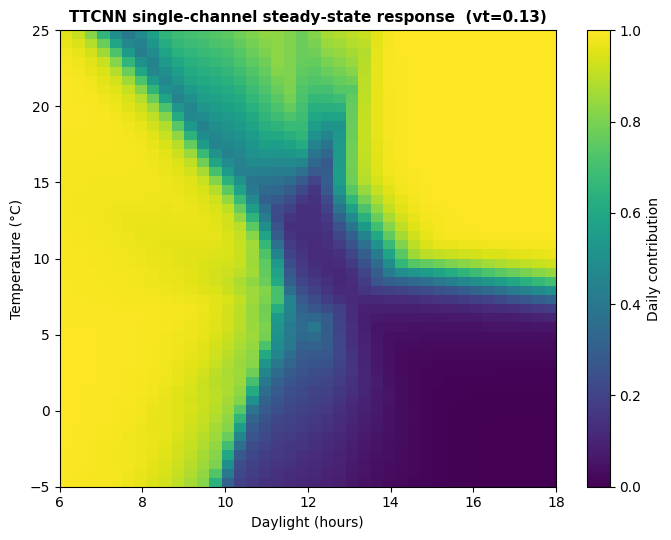

In [24]:
@torch.no_grad()
def plot_hybrid_response_2d(model, t_range=(-5, 25), d_range=(6, 18),
                            n_t=50, n_d=40, seq_len=120, vu_cum=60.0):
    """2D response surface of the single TTCNN channel.

    Uses constant-valued sequences long enough to cover the receptive field.
    `vu_cum` sets the cumulative vernalization units seen by `vt` (so that
    `vt = clamp(vu_cum / threshold_vern, 0, 1)`) — default 60 saturates it.
    """
    model.eval()
    device = next(model.parameters()).device

    t_mean, t_std = model._feature_statistics['temperature_2m_mean']
    d_mean, d_std = model._feature_statistics['daylight_duration']

    t_vals = np.linspace(t_range[0], t_range[1], n_t)
    d_vals = np.linspace(d_range[0], d_range[1], n_d)  # hours

    t_norm = (t_vals - t_mean) / t_std
    d_norm = (d_vals * 3600.0 - d_mean) / d_std

    pf_vec = np.clip((d_vals - model._p_base) /
                      (model._p_saturation - model._p_base), 0, 1)
    vt_const = float(np.clip(vu_cum / model._threshold_vern, 0, 1))

    T_g, D_g = np.meshgrid(t_norm, d_norm, indexing='ij')
    _, PF_g  = np.meshgrid(t_norm, pf_vec, indexing='ij')

    T_flat  = torch.tensor(T_g.reshape(-1),  dtype=torch.float32, device=device)
    D_flat  = torch.tensor(D_g.reshape(-1),  dtype=torch.float32, device=device)
    PF_flat = torch.tensor(PF_g.reshape(-1), dtype=torch.float32, device=device)
    VT_flat = torch.full_like(T_flat, vt_const)

    x = torch.stack([
        T_flat.unsqueeze(1).expand(-1, seq_len),
        D_flat.unsqueeze(1).expand(-1, seq_len),
        VT_flat.unsqueeze(1).expand(-1, seq_len),
        PF_flat.unsqueeze(1).expand(-1, seq_len),
    ], dim=1)  # (n_t*n_d, 4, seq_len)

    out = model._ttcnn(x)[:, 0, -1].cpu().numpy().reshape(n_t, n_d)

    fig, ax = plt.subplots(figsize=(7, 5.5))
    im = ax.imshow(
        out, origin='lower', aspect='auto',
        extent=[d_range[0], d_range[1], t_range[0], t_range[1]],
        cmap='viridis', vmin=0, vmax=1,
    )
    plt.colorbar(im, ax=ax, label='Daily contribution')
    ax.set_xlabel('Daylight (hours)', fontsize=10)
    ax.set_ylabel('Temperature (°C)', fontsize=10)
    ax.set_title(
        f'TTCNN single-channel steady-state response  (vt={vt_const:.2f})',
        fontsize=11, fontweight='bold',
    )
    plt.tight_layout()
    plt.show()

plot_hybrid_response_2d(hybrid, vu_cum=60.0)   # vt saturated
plot_hybrid_response_2d(hybrid, vu_cum=5.0)    # vt still low

## 7. Season dynamics

For each held-out season: temperature, the gating inputs `vt` and `pf`,
the daily contribution, cumulative, and the heading probability curve.

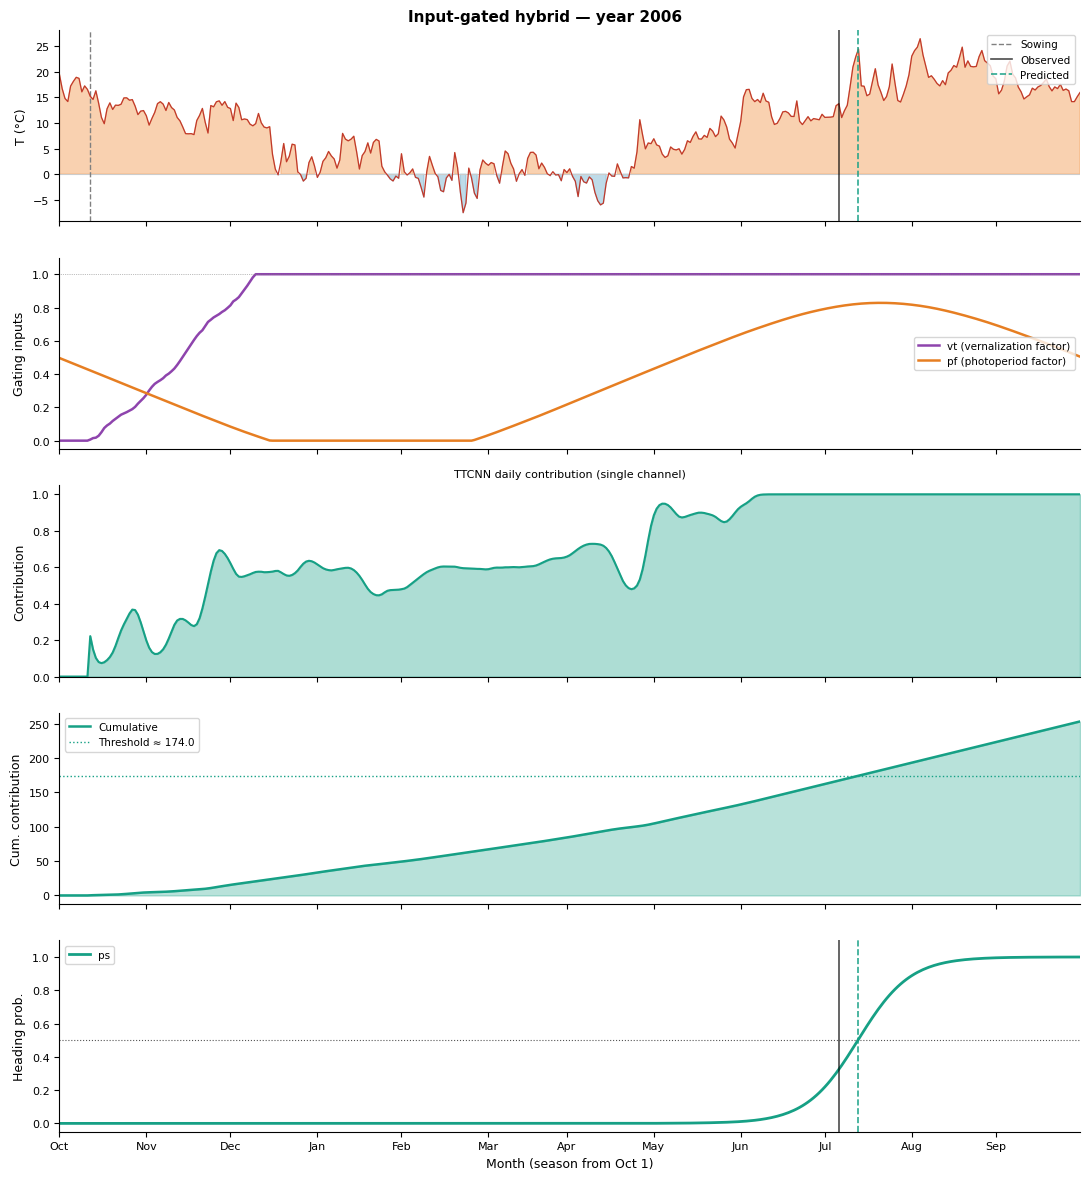

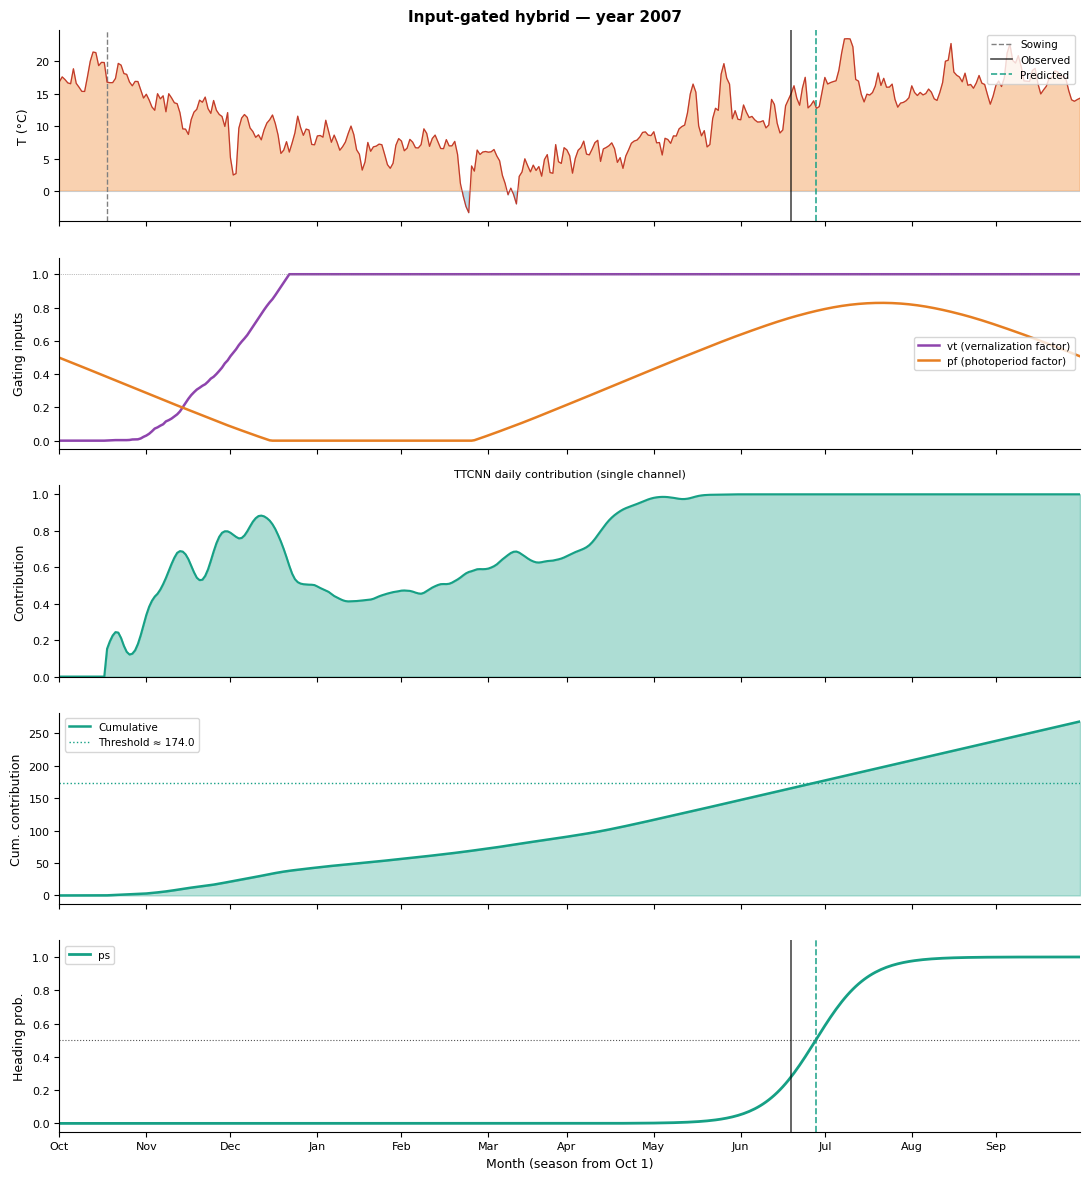

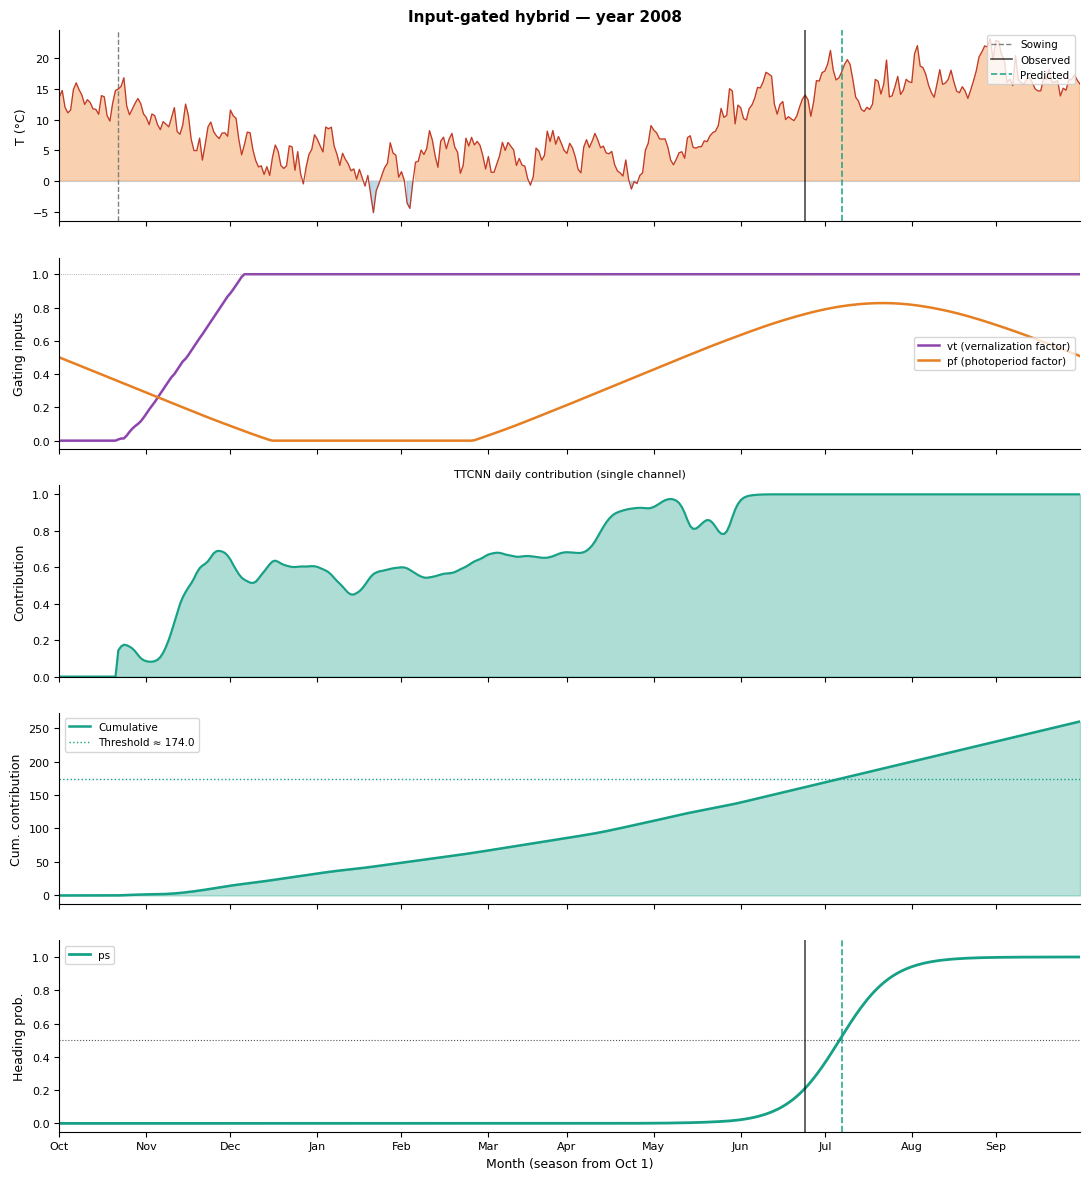

In [25]:
@torch.no_grad()
def plot_hybrid_season(model, sample, obs_ix=None, title=''):
    model.eval()
    device = next(model.parameters()).device
    t_sample = PVTTInputHybridModel.cast_to_tensor(sample, device=device)
    batch    = PVTTInputHybridModel.collate_fn([t_sample])
    ixs, info = model(batch)

    pred_ix = int(ixs[0].item() + 0.5)
    ts      = sample[KEY_FEATURES]['temperature_2m_mean'].astype(float)
    n       = len(ts)
    days    = np.arange(n)
    sow_ix  = int(sample[KEY_OBSERVATIONS_INDEX][SOW_KEY])

    vt      = info['vt'][0].cpu().numpy()
    pf      = info['pf'][0].cpu().numpy()
    contrib = info['contrib'][0].cpu().numpy()
    cumul   = info['cumul'][0].cpu().numpy()
    ps      = info['ps'][0].cpu().numpy()
    th      = model._threshold.threshold.item() * 365.0

    color   = MODEL_COLORS['InputHybrid']
    color_v = MODEL_COLORS['vt']
    color_p = MODEL_COLORS['pf']

    fig, axes = plt.subplots(5, 1, figsize=(11, 12), sharex=True)
    if title:
        fig.suptitle(title, fontsize=11, fontweight='bold')

    ax = axes[0]
    ax.axhline(0, color=PALETTE['zero'], lw=0.8)
    ax.axvline(sow_ix, color='grey', lw=1.0, ls='--', label='Sowing')
    ax.fill_between(days, ts, 0, where=(ts>=0), color=PALETTE['temp_warm'])
    ax.fill_between(days, ts, 0, where=(ts<0),  color=PALETTE['temp_cold'])
    ax.plot(days, ts, color=PALETTE['temp_line'], lw=0.9)
    if obs_ix is not None:
        ax.axvline(obs_ix, color='black', lw=1.2, ls='-', alpha=0.7, label='Observed')
    ax.axvline(pred_ix, color=color, lw=1.2, ls='--', alpha=0.9, label='Predicted')
    _style_ax(ax, n, ylabel='T (°C)')
    ax.legend(fontsize=7.5, loc='upper right')

    ax = axes[1]
    ax.plot(days, vt, color=color_v, lw=1.8, label='vt (vernalization factor)')
    ax.plot(days, pf, color=color_p, lw=1.8, label='pf (photoperiod factor)')
    ax.axhline(1.0, color='grey', lw=0.5, ls=':')
    ax.set_ylim(-0.05, 1.1)
    _style_ax(ax, n, ylabel='Gating inputs')
    ax.legend(fontsize=7.5, loc='center right')

    ax = axes[2]
    ax.fill_between(days, contrib, color=color, alpha=0.35)
    ax.plot(days, contrib, color=color, lw=1.5)
    ax.set_ylim(0, 1.05)
    _style_ax(ax, n, ylabel='Contribution')
    ax.set_title('TTCNN daily contribution (single channel)', fontsize=8)

    ax = axes[3]
    ax.fill_between(days, cumul, color=color, alpha=0.3)
    ax.plot(days, cumul, color=color, lw=1.8, label='Cumulative')
    ax.axhline(th, color=color, lw=1.0, ls=':', label=f'Threshold ≈ {th:.1f}')
    _style_ax(ax, n, ylabel='Cum. contribution')
    ax.legend(fontsize=7.5)

    ax = axes[4]
    ax.plot(days, ps, color=color, lw=2.0, label='ps')
    ax.axhline(0.5, color=PALETTE['thresh'], lw=0.8, ls=':')
    if obs_ix is not None:
        ax.axvline(obs_ix, color='black', lw=1.2, ls='-', alpha=0.7)
    ax.axvline(pred_ix, color=color, lw=1.2, ls='--', alpha=0.9)
    ax.set_ylim(-0.05, 1.1)
    _style_ax(ax, n, ylabel='Heading prob.', xlabel=True)
    ax.legend(fontsize=7.5, loc='upper left')

    plt.tight_layout()
    plt.show()

for year in years_to_show:
    sample = pick_sample(ds_tst, year)
    obs_date = sample['observations'][OBS_KEY]
    obs_ix   = int((np.datetime64(obs_date, 'D')
                    - np.datetime64(sample['season_start'], 'D'))
                   / np.timedelta64(1, 'D'))
    plot_hybrid_season(hybrid, sample, obs_ix=obs_ix,
                       title=f'Input-gated hybrid — year {year}')

## 8. Synthetic sensitivity sweep — winter temperature

Same sweep as the original notebook.  A model with the correct inductive
bias should predict later heading when winters are too warm (insufficient
vernalization) — here that pressure comes *through* the `vt` input, not
from something the network had to discover from raw temperature.

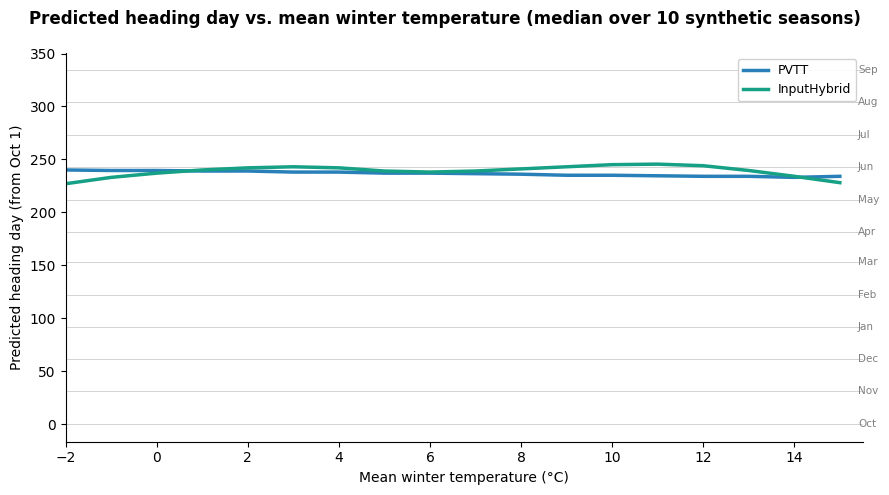

In [26]:
def _daylight_series(n=365):
    days = np.arange(n)
    return (12.0 - 4.0 * np.cos(2 * np.pi * (days - 81) / 365)) * 3600.0


def generate_wheat_sample(mean_winter_temp, mean_spring_temp=12.0,
                          noise_std=1.5, sow_ix=30, seed=0,
                          season_start=np.datetime64('1990-10-01')):
    rng = np.random.default_rng(seed)
    ts  = np.zeros(365)
    ts[0:sow_ix]   = 10.0
    ts[sow_ix:150] = mean_winter_temp
    ts[150:250]    = mean_spring_temp
    ts[250:365]    = 18.0
    ts += rng.normal(0, noise_std, 365)
    return {
        KEY_FEATURES: {
            'temperature_2m_mean': ts.astype(np.float32),
            'daylight_duration':   _daylight_series(365).astype(np.float32),
        },
        KEY_OBSERVATIONS_INDEX: {'BBCH_0': sow_ix},
        'season_start': np.datetime64(season_start)
            if isinstance(season_start, str) else season_start,
        'observations': {},
    }


WINTER_TEMPS = np.arange(-2, 16, 1.0)
N_SEEDS = 10
SOW_IX  = 30

pvtt_bloom   = []
hybrid_bloom = []
hybrid.eval()

for mw in WINTER_TEMPS:
    p_seeds, h_seeds = [], []
    for seed in range(N_SEEDS):
        sample = generate_wheat_sample(mean_winter_temp=mw, seed=seed, sow_ix=SOW_IX)
        _, info_p = pvtt.predict(sample)
        p_seeds.append(info_p['ix'])
        with torch.no_grad():
            t_s   = PVTTInputHybridModel.cast_to_tensor(sample)
            batch = PVTTInputHybridModel.collate_fn([t_s])
            ixs, _ = hybrid(batch)
        h_seeds.append(int(ixs[0].item() + 0.5))
    pvtt_bloom.append(np.median(p_seeds))
    hybrid_bloom.append(np.median(h_seeds))

pvtt_bloom   = np.array(pvtt_bloom)
hybrid_bloom = np.array(hybrid_bloom)

fig, ax = plt.subplots(figsize=(9, 5))
fig.suptitle('Predicted heading day vs. mean winter temperature '
             '(median over 10 synthetic seasons)',
             fontsize=12, fontweight='bold')

for doy, month in zip(_MONTH_STARTS, _MONTH_LABELS):
    ax.axhline(doy, color='lightgrey', lw=0.7, zorder=0)
    ax.text(15.4, doy, month, fontsize=7.5, va='center', color='grey')

valid_p = pvtt_bloom < 364
ax.plot(WINTER_TEMPS[valid_p], pvtt_bloom[valid_p],
        color=MODEL_COLORS['PVTT'], lw=2.5, label='PVTT')
valid_h = hybrid_bloom < 364
ax.plot(WINTER_TEMPS[valid_h], hybrid_bloom[valid_h],
        color=MODEL_COLORS['InputHybrid'], lw=2.5, label='InputHybrid')

ax.set_xlabel('Mean winter temperature (°C)', fontsize=10)
ax.set_ylabel('Predicted heading day (from Oct 1)', fontsize=10)
ax.legend(fontsize=9, framealpha=0.9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlim(-2, 15.5)
plt.tight_layout()
plt.show()